In [232]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/Users/jack/Documents/B2-American-Airlines-Delay-Prediction-Project/data/raw/sequence_spoilage.csv', sep="|")
df.columns = df.columns.str.strip()

In [233]:
# List of variables
print(df.columns)

Index(['Unnamed: 0', 'SEQ_NBR', 'SEQ_SCHD_START_DT', 'FLEET', 'BASE',
       'DIVISION', 'SPOILAGE', 'TOTAL_BLOCKED_HRS', 'TOTAL_SPOILED_HRS',
       'SEQ_CAL_DAYS', 'SEQ_DUTY_DAYS', 'SEQ_TTL_FLTTIME',
       'MIN_FLYTIME_PER_LEG', 'MAX_LEGS_PER_DAY', 'SEQ_TTL_LEGS',
       'MORETHAN2_321_LEGS', 'IN_SEQ_DHD', 'LAYOVER', 'SEQ_PATTERN',
       'SEQ_START', 'FLIGHT_PATTERN', 'SEQ_START_HRS', 'SF_LOAD_TMS'],
      dtype='object')


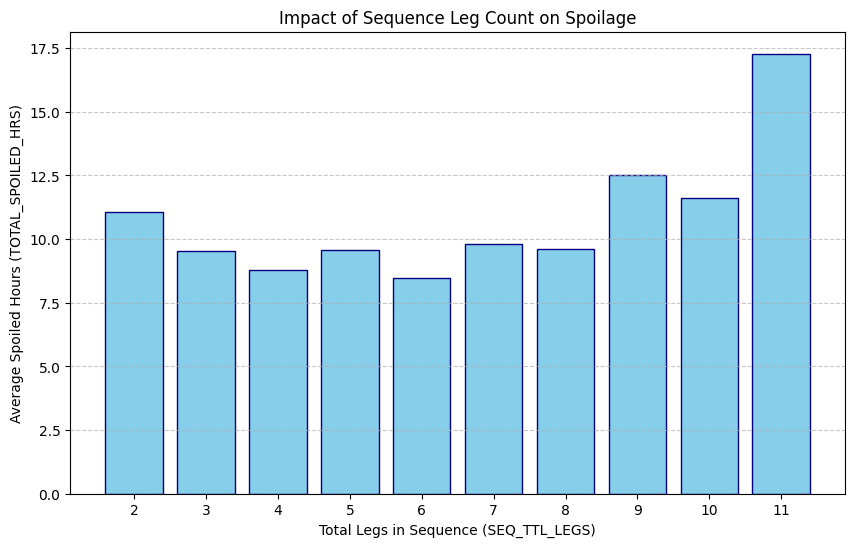

In [234]:
# Behavior when more than 3 legs are in a sequence — bar chart of disruption rate by leg count

analysis_data = df.groupby('SEQ_TTL_LEGS')['TOTAL_SPOILED_HRS'].mean().reset_index()

analysis_data = analysis_data.sort_values('SEQ_TTL_LEGS')

# Create graph
plt.figure(figsize=(10, 6))
plt.bar(analysis_data['SEQ_TTL_LEGS'].astype(str), 
        analysis_data['TOTAL_SPOILED_HRS'], 
        color='skyblue', 
        edgecolor='navy')

# Labels and Title
plt.xlabel('Total Legs in Sequence (SEQ_TTL_LEGS)')
plt.ylabel('Average Spoiled Hours (TOTAL_SPOILED_HRS)')
plt.title('Impact of Sequence Leg Count on Spoilage')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

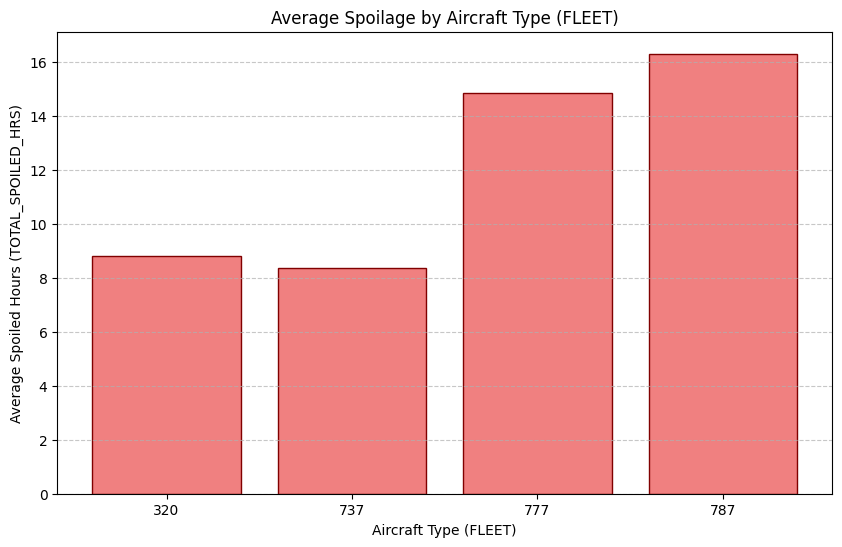

In [235]:
# Bar chart of average spoilage by aircraft type

# Grouping
fleet_analysis = df.groupby('FLEET')['TOTAL_SPOILED_HRS'].mean().reset_index()

plt.figure(figsize=(10, 6))

# Aircraft type to string so they show up as categories not continuous numbers
plt.bar(fleet_analysis['FLEET'].astype(str), 
        fleet_analysis['TOTAL_SPOILED_HRS'], 
        color='lightcoral', 
        edgecolor='maroon')

plt.xlabel('Aircraft Type (FLEET)')
plt.ylabel('Average Spoiled Hours (TOTAL_SPOILED_HRS)')
plt.title('Average Spoilage by Aircraft Type (FLEET)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

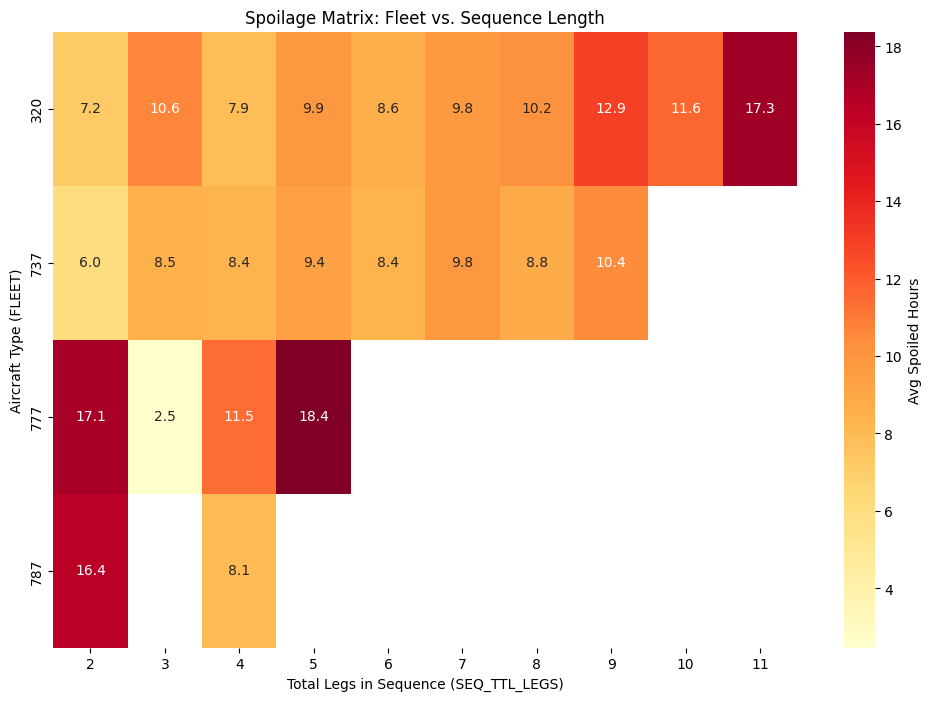

In [236]:
# Pivot table with aircraft type, legs, and spoilage

# Create matrix
matrix_df = df.pivot_table(
    index='FLEET', 
    columns='SEQ_TTL_LEGS', 
    values='TOTAL_SPOILED_HRS', 
    aggfunc='mean'
)

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(matrix_df, annot=True, cmap='YlOrRd', fmt=".1f", cbar_kws={'label': 'Avg Spoiled Hours'})

plt.title('Spoilage Matrix: Fleet vs. Sequence Length')
plt.xlabel('Total Legs in Sequence (SEQ_TTL_LEGS)')
plt.ylabel('Aircraft Type (FLEET)')

plt.show()

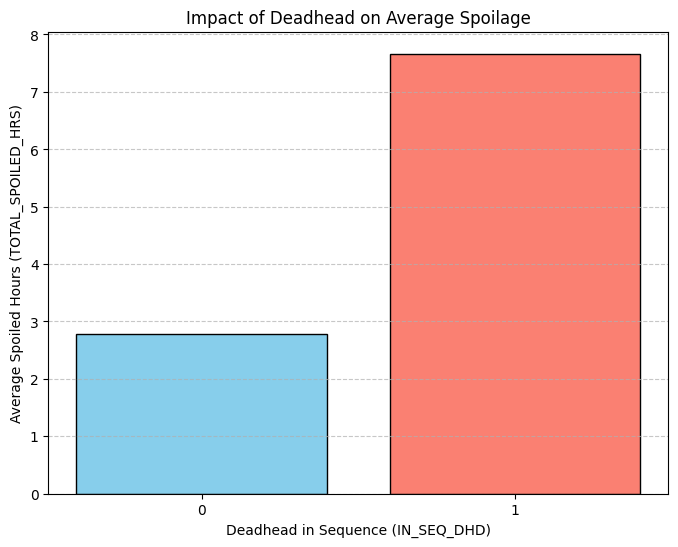

In [ ]:
# Deadhead vs. Spoilage

#Binarize the variable
df['IN_SEQ_DHD'] = df['IN_SEQ_DHD'].replace(2, 1)
df[['TOTAL_SPOILED_HRS']] = df[['TOTAL_SPOILED_HRS']].fillna(0)

dhd_analysis = df.groupby('IN_SEQ_DHD')['TOTAL_SPOILED_HRS'].mean().reset_index()


# Create a Bar Chart
plt.figure(figsize=(8, 6))
plt.bar(dhd_analysis['IN_SEQ_DHD'].astype(str), 
        dhd_analysis['TOTAL_SPOILED_HRS'], 
        color=['skyblue', 'salmon'], 
        edgecolor='black')

plt.ylabel('Average Spoiled Hours (TOTAL_SPOILED_HRS)')
plt.title('Impact of Deadhead on Average Spoilage')
plt.xlabel('Deadhead in Sequence (IN_SEQ_DHD)')
plt.grid(axis='y', linestyle='--', alpha=0.7)


In [238]:
from scipy import stats

# Separate groups
group_with_dhd = df[df['IN_SEQ_DHD'] == 1]['TOTAL_SPOILED_HRS']
group_no_dhd = df[df['IN_SEQ_DHD'] == 0]['TOTAL_SPOILED_HRS']

# One-tailed T test for significance of directional relationship
t_stat, p_val_t = stats.ttest_ind(group_with_dhd, group_no_dhd, equal_var=False, alternative='greater')

# Point biserial correlation (chat said to use :)
correlation, p_val_corr = stats.pointbiserialr(df['IN_SEQ_DHD'], df['TOTAL_SPOILED_HRS'])

print(f"--- Directional Statistical Analysis (One-Tailed) ---")
print(f"Mean Spoilage (With Deadhead): {group_with_dhd.mean():.3f}")
print(f"Mean Spoilage (No Deadhead): {group_no_dhd.mean():.3f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value (One-Tailed): {p_val_t:.4e}")
print(f"Correlation Coefficient: {correlation:.4f}")

alpha = 0.01
if p_val_t < alpha:
    print(f"\nCONCLUSION: Statistically Significant (Directional).")
    print(f"Evidence suggests deadheads significantly INCREASE spoilage (p < {alpha}).")
else:
    print("\nCONCLUSION: NOT statistically significant.")
    print("We cannot conclude that deadheads increase spoilage at this confidence level.")

--- Directional Statistical Analysis (One-Tailed) ---
Mean Spoilage (With Deadhead): 7.667
Mean Spoilage (No Deadhead): 2.773
T-statistic: 10.2908
P-value (One-Tailed): 5.3511e-21
Correlation Coefficient: 0.1404

CONCLUSION: Statistically Significant (Directional).
Evidence suggests deadheads significantly INCREASE spoilage (p < 0.01).
